In [1]:
library(clusterProfiler)
library(org.Mm.eg.db)
library(tidyverse)
library(biomaRt)
library(enrichplot)

Warning message:
“package ‘clusterProfiler’ was built under R version 4.3.2”


clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colname

# RGC DEG

In [2]:
up_deg <- list()
down_deg <- list()
deg <- read.csv('data/snRNA_data/DEG/Retinal ganglion cell.csv')
for(w in c(2,4,8)){
    up <- deg[deg[,(log2(w)-1)*5 + 5]<0.01 & deg[,(log2(w)-1)*5 + 3]>=0.25,(log2(w)-1)*5 + 1] %>% bitr(fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db)
    down <- deg[deg[,(log2(w)-1)*5 + 5]<0.01 & deg[,(log2(w)-1)*5 + 3]<=-0.25,(log2(w)-1)*5 + 1] %>% bitr(fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db)
    up_deg <- c(up_deg, ifelse(length(up)>0, list(up$ENTREZID), list())) 
    down_deg <- c(down_deg, ifelse(length(down)>0, list(down$ENTREZID), list())) 
}
names(up_deg) <- c('2w','4w','8w')
names(down_deg) <- c('2w','4w','8w')

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(., fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“10.62% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(., fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“3.42% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(., fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“6.86% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(., fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“4.35% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(., fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“7.19% of input gene IDs are fail to map...”
'select()' returned 1:1 

In [3]:
gobp_results2 <- enrichGO(gene = up_deg$`2w`, OrgDb = org.Mm.eg.db, keyType = "ENTREZID", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)
gobp_results4 <- enrichGO(gene = up_deg$`4w`, OrgDb = org.Mm.eg.db, keyType = "ENTREZID", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)
gobp_results8 <- enrichGO(gene = up_deg$`8w`, OrgDb = org.Mm.eg.db, keyType = "ENTREZID", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)

In [4]:
df_bp2 <- as.data.frame(gobp_results2) %>% .[,c('Description','qvalue')]
df_bp2$Category <- "2w"
df_bp4 <- as.data.frame(gobp_results4) %>% .[,c('Description','qvalue')]
df_bp4$Category <- "4w"
df_bp8 <- as.data.frame(gobp_results8) %>% .[,c('Description','qvalue')]
df_bp8$Category <- "8w"

In [5]:
df_bp2 <- df_bp2 %>%
  filter(Description %in% c("retina homeostasis",
                            "detection of abiotic stimulus",
                            "cilium organization",
                            "calcium ion import",
                            "mechanoreceptor differentiation"))
df_bp4 <- df_bp4 %>%
  filter(Description %in% c("extracellular matrix organization",
                            "Wnt signaling pathway",
                            "axon guidance",
                            "calcium ion transport",
                            "regulation of ERK1 and ERK2 cascade"))
df_bp8 <- df_bp8 %>%
  filter(Description %in% c("detection of abiotic stimulus",
                            "neural retina development",
                            "regulation of apoptotic signaling pathway",
                            "regulation of Wnt signaling pathway",
                            "oxidative phosphorylation",
                            "response to endoplasmic reticulum stress"))

In [6]:
plot_data <- rbind(df_bp2, df_bp4, df_bp8)
plot_data$logQ <- -log10(plot_data$qvalue)

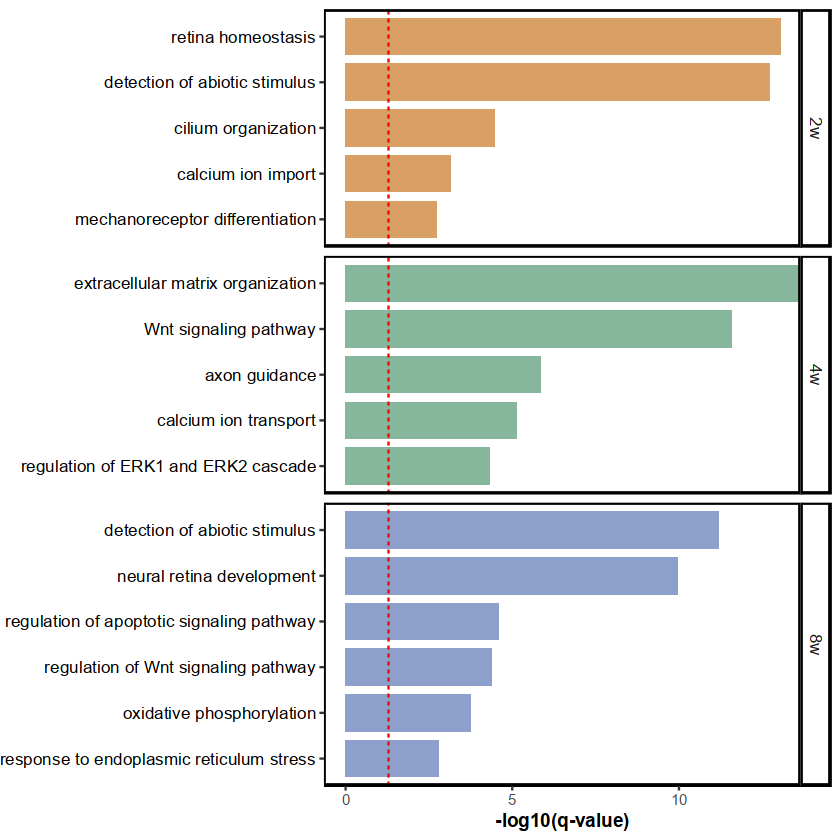

In [7]:
ggplot(plot_data, aes(x = logQ, y = reorder(Description, logQ))) +
  geom_col(aes(fill = Category), width = 0.8) +
  coord_cartesian(xlim = c(0, 13)) +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  geom_vline(xintercept = -log10(0.05), color = "red", linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = c("2w" = "#D9A066", "8w" = "#8DA0CB", "4w" = "#86B79D")) +
  theme_bw() +
  labs(x = "-log10(q-value)", y = NULL) +
  theme(
    strip.background = element_rect(fill = "white", color = "black", linewidth = 1),
    strip.text = element_text(size = 10),
    strip.text.y = element_text(angle = 270),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.y = element_blank(),
    axis.text.y = element_text(color = "black", size = 10),panel.grid = element_blank(),legend.position = "none",
    axis.title.x = element_text(face = "bold")
  )

In [8]:
kegg_results2 <- enrichKEGG(gene = up_deg$`2w`, organism = 'mmu', pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)
kegg_results4 <- enrichKEGG(gene = up_deg$`4w`, organism = 'mmu', pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)
kegg_results8 <- enrichKEGG(gene = up_deg$`8w`, organism = 'mmu', pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)

Reading KEGG annotation online: "https://rest.kegg.jp/link/mmu/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/mmu"...



In [9]:
kegg_results2@result$Description <- str_remove(kegg_results2@result$Description, "\\s+-\\s+Mus\\s+musculus\\s+\\(house\\s+mouse\\)")
kegg_results4@result$Description <- str_remove(kegg_results4@result$Description, "\\s+-\\s+Mus\\s+musculus\\s+\\(house\\s+mouse\\)")
kegg_results8@result$Description <- str_remove(kegg_results8@result$Description, "\\s+-\\s+Mus\\s+musculus\\s+\\(house\\s+mouse\\)")

In [10]:
df_kegg2 <- as.data.frame(kegg_results2) %>% .[,c('Description','qvalue')]
df_kegg2$Category <- "2w"
df_kegg4 <- as.data.frame(kegg_results4) %>% .[,c('Description','qvalue')]
df_kegg4$Category <- "4w"
df_kegg8 <- as.data.frame(kegg_results8) %>% .[,c('Description','qvalue')]
df_kegg8$Category <- "8w"

In [11]:
df_kegg4 <- df_kegg4 %>%
  filter(Description %in% c("Integrin signaling",
                            "ECM-receptor interaction",
                            "Cytoskeleton in muscle cells",
                            "PI3K-Akt signaling pathway",
                            "Calcium signaling pathway",
                            "Wnt signaling pathway"))
df_kegg8 <- df_kegg8 %>%
  filter(Description %in% c("Ribosome",
                            "Coronavirus disease",
                            "Parkinson disease",
                            "Huntington disease",
                            "Chemical carcinogenesis - reactive oxygen species",
                            "Hippo signaling pathway",
                            "Oxidative phosphorylation",
                            "Alzheimer disease",
                            "PI3K-Akt signaling pathway"))

In [12]:
plot_data <- rbind(df_kegg2, df_kegg4, df_kegg8)
plot_data$logQ <- -log10(plot_data$qvalue)

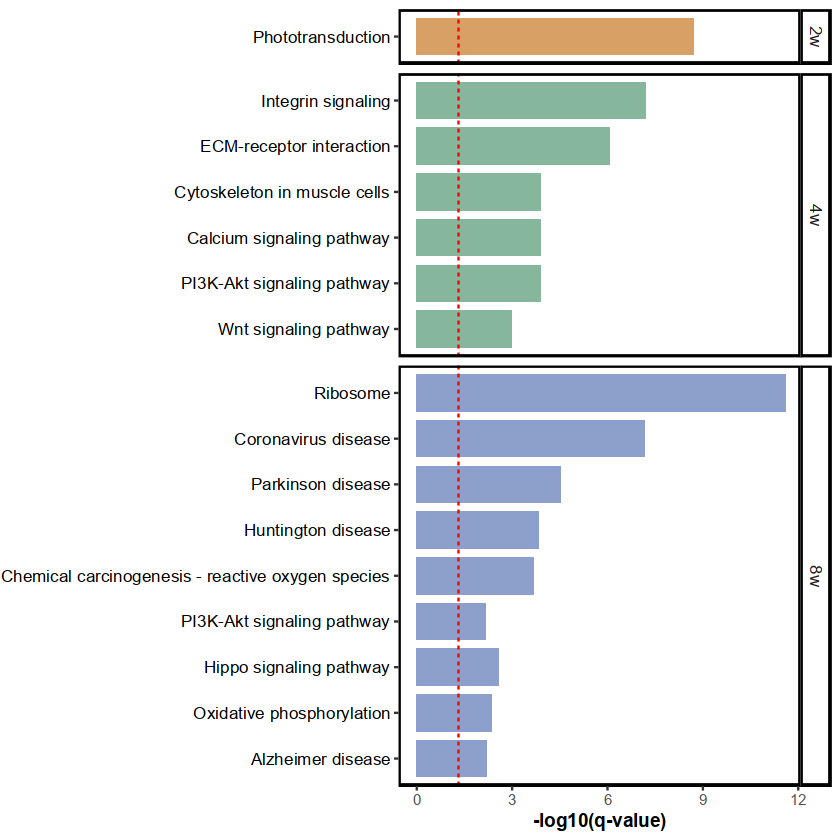

In [13]:
ggplot(plot_data, aes(x = logQ, y = reorder(Description, logQ))) +
  geom_col(aes(fill = Category), width = 0.8) +
  coord_cartesian(xlim = c(0, 11.5)) +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  geom_vline(xintercept = -log10(0.05), color = "red", linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = c("2w" = "#D9A066", "8w" = "#8DA0CB", "4w" = "#86B79D")) +
  theme_bw() +
  labs(x = "-log10(q-value)", y = NULL) +
  theme(
    strip.background = element_rect(fill = "white", color = "black", linewidth = 1),
    strip.text = element_text(size = 10),
    strip.text.y = element_text(angle = 270),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.y = element_blank(),
    axis.text.y = element_text(color = "black", size = 10),panel.grid = element_blank(),legend.position = "none",
    axis.title.x = element_text(face = "bold")
  )

# scMEGA

In [14]:
f <- read.csv('data/scMEGA/scMEGA_filtered_valid.csv')
head(f)

,tf,gene,correlation,tf_z_score,gene_z_score,regulation
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,Creb3l2,C2cd2l,0.5914570,0.7353763,0.4434680,positive
2,Creb3l2,Chsy1,0.5810401,0.7353763,0.4044614,positive
3,Creb3l2,Dusp15,0.6639588,0.7353763,0.4290570,positive
4,Creb3l2,Kmt5c,0.6244333,0.7353763,0.4997339,positive
5,Creb3l2,Mmd2,0.5750985,0.7353763,0.4400448,positive
6,Creb3l2,Nlk,0.5457982,0.7353763,3.4371802,positive


In [15]:
genes <- c(unique(f$gene),unique(f$tf))

In [16]:
gobp_results <- enrichGO(gene = genes, OrgDb = org.Mm.eg.db, keyType = "SYMBOL", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)

In [17]:
genes <- bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db)$ENTREZID
kegg_results <- enrichKEGG(gene = genes, organism = 'mmu', pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.05)
kegg_results <- setReadable(kegg_results, OrgDb = org.Mm.eg.db, keyType = "ENTREZID")

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“1.92% of input gene IDs are fail to map...”


In [18]:
kegg_results@result$Description <- str_remove(kegg_results@result$Description, "\\s+-\\s+Mus\\s+musculus\\s+\\(house\\s+mouse\\)")

In [19]:
df_bp <- as.data.frame(gobp_results) %>% .[,c('Description','qvalue')]
df_bp$Category <- "GO:BP"

df_kegg <- as.data.frame(kegg_results) %>% .[,c('Description','qvalue')]
df_kegg$Category <- "KEGG"

In [20]:
df_bp <- df_bp %>%
  filter(grepl(paste0(c("neuron projection arborization",
                        "regulation of monoatomic ion transmembrane transport",
                        "regulation of Wnt signaling pathway",
                        "developmental maturation",
                        "regulation of G protein-coupled receptor signaling pathway"),collapse='|'), Description, ignore.case = TRUE))
df_kegg <- df_kegg %>%
  filter(grepl(paste0(c("Pathways of neurodegeneration - multiple diseases",
                        "Glutamatergic synapse"),collapse='|'), Description, ignore.case = TRUE))

In [21]:
df_bp

,Description,qvalue,Category
,<chr>,<dbl>,<chr>
GO:0021700,developmental maturation,0.0003941411,GO:BP
GO:0140058,neuron projection arborization,0.0010745637,GO:BP
GO:0034765,regulation of monoatomic ion transmembrane transport,0.0010745637,GO:BP
GO:0030111,regulation of Wnt signaling pathway,0.0035903891,GO:BP
GO:0150011,regulation of neuron projection arborization,0.0035903891,GO:BP
GO:0008277,regulation of G protein-coupled receptor signaling pathway,0.0055636255,GO:BP


In [22]:
df_kegg

,Description,qvalue,Category
,<chr>,<dbl>,<chr>
mmu05022,Pathways of neurodegeneration - multiple diseases,0.03914095,KEGG
mmu04724,Glutamatergic synapse,0.04259946,KEGG


In [23]:
plot_data <- rbind(df_bp, df_kegg)
plot_data$logQ <- -log10(plot_data$qvalue)

In [24]:
plot_data

,Description,qvalue,Category,logQ
,<chr>,<dbl>,<chr>,<dbl>
GO:0021700,developmental maturation,0.0003941411,GO:BP,3.404348
GO:0140058,neuron projection arborization,0.0010745637,GO:BP,2.968768
GO:0034765,regulation of monoatomic ion transmembrane transport,0.0010745637,GO:BP,2.968768
GO:0030111,regulation of Wnt signaling pathway,0.0035903891,GO:BP,2.444858
GO:0150011,regulation of neuron projection arborization,0.0035903891,GO:BP,2.444858
GO:0008277,regulation of G protein-coupled receptor signaling pathway,0.0055636255,GO:BP,2.254642
mmu05022,Pathways of neurodegeneration - multiple diseases,0.0391409504,KEGG,1.407369
mmu04724,Glutamatergic synapse,0.0425994591,KEGG,1.370596


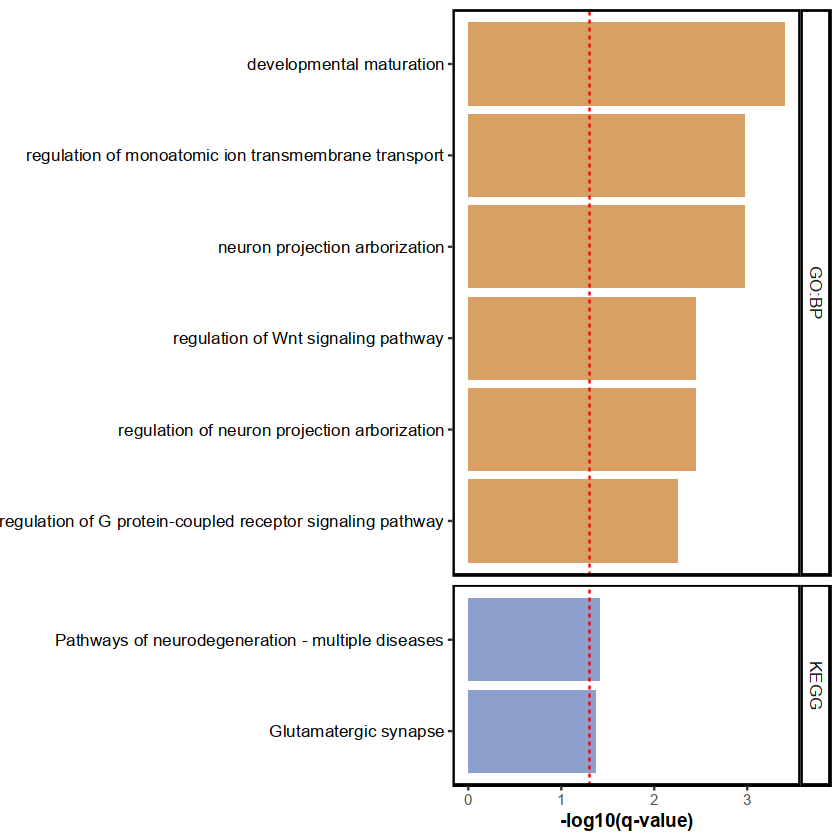

In [25]:
ggplot(plot_data, aes(x = logQ, y = reorder(Description, logQ))) +
  geom_col(aes(fill = Category), width = 0.9) +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  geom_vline(xintercept = -log10(0.05), color = "red", linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = c("GO:BP" = "#D9A066", "KEGG" = "#8DA0CB")) +
  theme_bw() +
  labs(x = "-log10(q-value)", y = NULL) +
  theme(
    strip.background = element_rect(fill = "white", color = "black", linewidth = 1),
    strip.text = element_text(size = 10),
    strip.text.y = element_text(angle = 270),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.y = element_blank(),
    axis.text.y = element_text(color = "black", size = 10),panel.grid = element_blank(),legend.position = "none",
    axis.title.x = element_text(face = "bold")
  )

# scenicplus

In [26]:
f <- read.csv('data/scenicplus/eRegulon_filtered.csv')
head(f)

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>
1,chr2:29191748-29192248,Setx,0.02720065,0.05160619,0.001403722,0.001403722,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(19g),Atf2_direct_+/+_(23r),0.8116782,1,0.05002154,2455
2,chr11:100951809-100952309,Atp6v0a1,0.02486377,0.05546716,0.001379122,0.001379122,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(19g),Atf2_direct_+/+_(23r),0.6932231,1,0.05766146,2527
3,chr12:82122322-82122822,Sipa1l1,0.06120775,0.15518410,0.009498469,0.009498469,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(19g),Atf2_direct_+/+_(23r),0.3606076,1,0.07137441,1099
4,chr17:5997360-5997860,Synj2,0.01821636,0.14565273,0.002653262,0.002653262,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(19g),Atf2_direct_+/+_(23r),1.0248056,1,0.06030657,2441
5,chr11:74496864-74497364,Rap1gap2,0.02544659,0.10731792,0.002730875,0.002730875,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(19g),Atf2_direct_+/+_(23r),1.0266100,1,0.05822589,2447
6,chr11:51756240-51756740,Sec24a,0.07139795,0.07712766,0.005506757,0.005506757,Atf2,False,Atf2_direct_+/+,Atf2_direct_+/+_(19g),Atf2_direct_+/+_(23r),1.5390838,1,0.05880066,241


In [27]:
genes <- c(unique(f$Gene),unique(f$TF))

In [28]:
gobp_results <- enrichGO(gene = genes, OrgDb = org.Mm.eg.db, keyType = "SYMBOL", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)

In [29]:
genes <- bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db)$ENTREZID
kegg_results <- enrichKEGG(gene = genes, organism = 'mmu', pAdjustMethod = "BH", pvalueCutoff = 0.01, qvalueCutoff = 0.01)
kegg_results <- setReadable(kegg_results, OrgDb = org.Mm.eg.db, keyType = "ENTREZID")

'select()' returned 1:1 mapping between keys and columns



In [30]:
kegg_results@result$Description <- str_remove(kegg_results@result$Description, "\\s+-\\s+Mus\\s+musculus\\s+\\(house\\s+mouse\\)")

In [31]:
df_bp <- as.data.frame(gobp_results) %>% .[,c('Description','qvalue')]
df_bp$Category <- "GO:BP"

df_kegg <- as.data.frame(kegg_results) %>% .[,c('Description','qvalue')]
df_kegg$Category <- "KEGG"

In [32]:
df_bp <- df_bp %>%
  filter(Description %in% c("cell junction assembly",
                            "dendrite development",
                            "calcium ion transmembrane transport",
                            "regulation of Wnt signaling pathway",
                            "neuron apoptotic process",
                            "cytoskeleton-dependent intracellular transport",
                            "intracellular calcium ion homeostasis"))
df_kegg <- df_kegg %>%
  filter(Description %in% c("Axon guidance",
                            "cGMP-PKG signaling pathway",
                            "Calcium signaling pathway",
                            "MAPK signaling pathway",
                            "Pathways of neurodegeneration - multiple diseases"))

In [33]:
df_bp

,Description,qvalue,Category
,<chr>,<dbl>,<chr>
GO:0034329,cell junction assembly,7.208330e-27,GO:BP
GO:0016358,dendrite development,3.796998e-18,GO:BP
GO:0070588,calcium ion transmembrane transport,1.279136e-12,GO:BP
GO:0030111,regulation of Wnt signaling pathway,5.322284e-09,GO:BP
GO:0006874,intracellular calcium ion homeostasis,7.937979e-09,GO:BP
GO:0030705,cytoskeleton-dependent intracellular transport,9.733674e-09,GO:BP
GO:0051402,neuron apoptotic process,4.926887e-08,GO:BP


In [34]:
df_kegg

,Description,qvalue,Category
,<chr>,<dbl>,<chr>
mmu04360,Axon guidance,3.222430e-08,KEGG
mmu04022,cGMP-PKG signaling pathway,2.655647e-07,KEGG
mmu04020,Calcium signaling pathway,5.079871e-07,KEGG
mmu04010,MAPK signaling pathway,1.482387e-05,KEGG
mmu05022,Pathways of neurodegeneration - multiple diseases,1.785862e-03,KEGG


In [35]:
plot_data <- rbind(df_bp, df_kegg)
plot_data$logQ <- -log10(plot_data$qvalue)

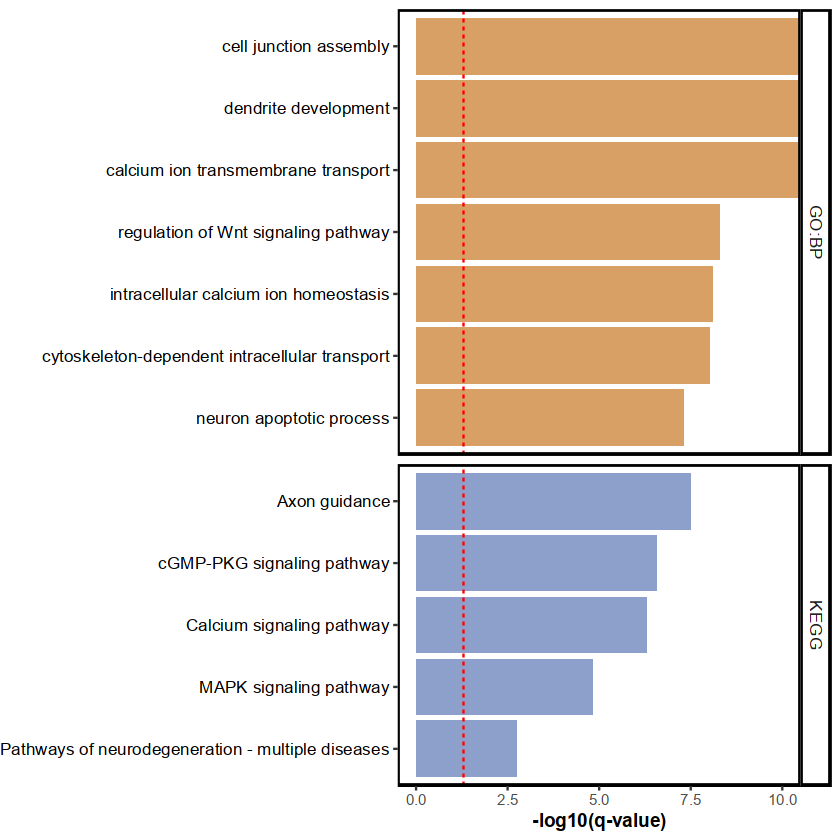

In [37]:
ggplot(plot_data, aes(x = logQ, y = reorder(Description, logQ))) +
  geom_col(aes(fill = Category), width = 0.9) +
  coord_cartesian(xlim = c(0, 10)) +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  geom_vline(xintercept = -log10(0.05), color = "red", linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = c("GO:BP" = "#D9A066", "KEGG" = "#8DA0CB")) +
  theme_bw() +
  labs(x = "-log10(q-value)", y = NULL) +
  theme(
    strip.background = element_rect(fill = "white", color = "black", linewidth = 1),
    strip.text = element_text(size = 10),
    strip.text.y = element_text(angle = 270),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.y = element_blank(),
    axis.text.y = element_text(color = "black", size = 10),panel.grid = element_blank(),legend.position = "none",
    axis.title.x = element_text(face = "bold")
  )

# GAM

In [38]:
f <- read.csv('data/GAM/kmeans_clusters.csv')

In [39]:
g1 <- f[f$gene_cluster %in% '1',1] %>% bitr(fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db)
g2 <- f[f$gene_cluster %in% '2',1] %>% bitr(fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db)
g3 <- f[f$gene_cluster %in% '3',1] %>% bitr(fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db)

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(., fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“9.34% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(., fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“15.61% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(., fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“4.63% of input gene IDs are fail to map...”


In [40]:
gobp_results1 <- enrichGO(gene = g1$ENTREZID, OrgDb = org.Mm.eg.db, keyType = "ENTREZID", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.05)
gobp_results2 <- enrichGO(gene = g2$ENTREZID, OrgDb = org.Mm.eg.db, keyType = "ENTREZID", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.05)
gobp_results3 <- enrichGO(gene = g3$ENTREZID, OrgDb = org.Mm.eg.db, keyType = "ENTREZID", ont = "BP", pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.05)

In [41]:
df_bp1 <- as.data.frame(gobp_results1) %>% .[,c('Description','qvalue')]
df_bp1$Category <- "Cluster 1"
df_bp2 <- as.data.frame(gobp_results2) %>% .[,c('Description','qvalue')]
df_bp2$Category <- "Cluster 2"
df_bp3 <- as.data.frame(gobp_results3) %>% .[,c('Description','qvalue')]
df_bp3$Category <- "Cluster 3"

In [42]:
df_bp1 <- df_bp1 %>%
  filter(Description %in% c("response to endoplasmic reticulum stress",
                            "regulation of tyrosine phosphorylation of STAT protein",
                            "interferon-mediated signaling pathway",
                            "response to BMP",
                            "regulation of Wnt signaling pathway",
                            "regulation of apoptotic signaling pathway"))
df_bp3 <- df_bp3 %>%
  filter(Description %in% c("regulation of membrane potential",
                            "regulation of neurogenesis",
                            "exocytosis"))

In [52]:
plot_data <- df_bp1
plot_data$logQ <- -log10(plot_data$qvalue)

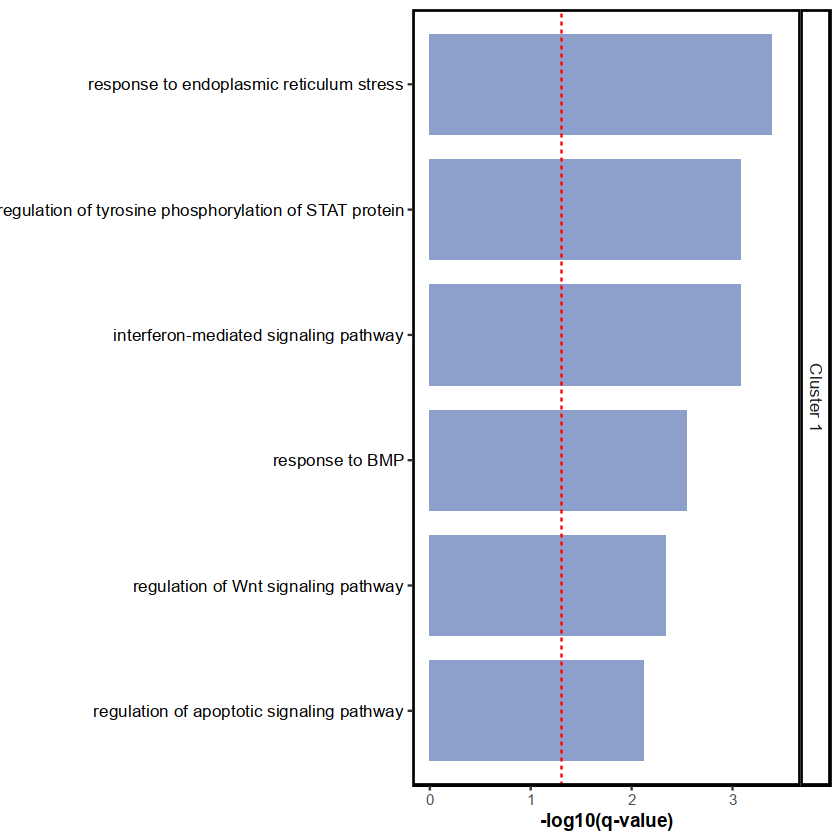

In [53]:
ggplot(plot_data, aes(x = logQ, y = reorder(Description, logQ))) +
  geom_col(aes(fill = Category), width = 0.8) +
  coord_cartesian(xlim = c(0, 3.5)) +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  geom_vline(xintercept = -log10(0.05), color = "red", linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = c("Cluster 1" = "#8DA0CB")) +
  theme_bw() +
  labs(x = "-log10(q-value)", y = NULL) +
  theme(
    strip.background = element_rect(fill = "white", color = "black", linewidth = 1),
    strip.text = element_text(size = 10),
    strip.text.y = element_text(angle = 270),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.y = element_blank(),
    axis.text.y = element_text(color = "black", size = 10),panel.grid = element_blank(),legend.position = "none",
    axis.title.x = element_text(face = "bold")
  )

In [54]:
plot_data <- df_bp2
plot_data$logQ <- -log10(plot_data$qvalue)

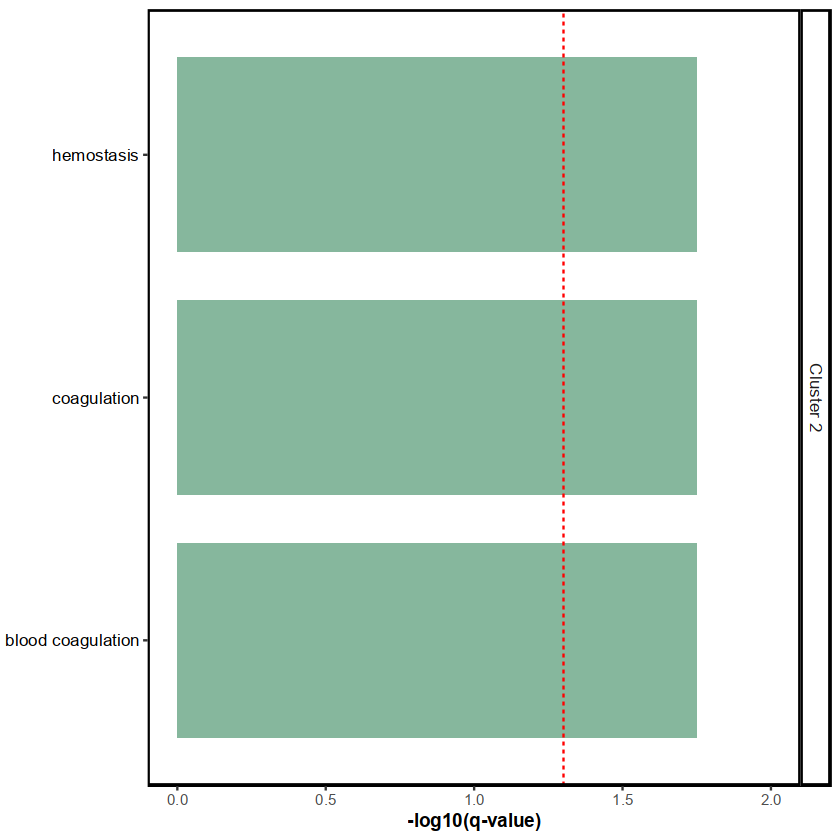

In [55]:
ggplot(plot_data, aes(x = logQ, y = reorder(Description, logQ))) +
  geom_col(aes(fill = Category), width = 0.8) +
  coord_cartesian(xlim = c(0, 2)) +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  geom_vline(xintercept = -log10(0.05), color = "red", linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = c("Cluster 2" = "#86B79D")) +
  theme_bw() +
  labs(x = "-log10(q-value)", y = NULL) +
  theme(
    strip.background = element_rect(fill = "white", color = "black", linewidth = 1),
    strip.text = element_text(size = 10),
    strip.text.y = element_text(angle = 270),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.y = element_blank(),
    axis.text.y = element_text(color = "black", size = 10),panel.grid = element_blank(),legend.position = "none",
    axis.title.x = element_text(face = "bold")
  )

In [56]:
plot_data <- df_bp3
plot_data$logQ <- -log10(plot_data$qvalue)

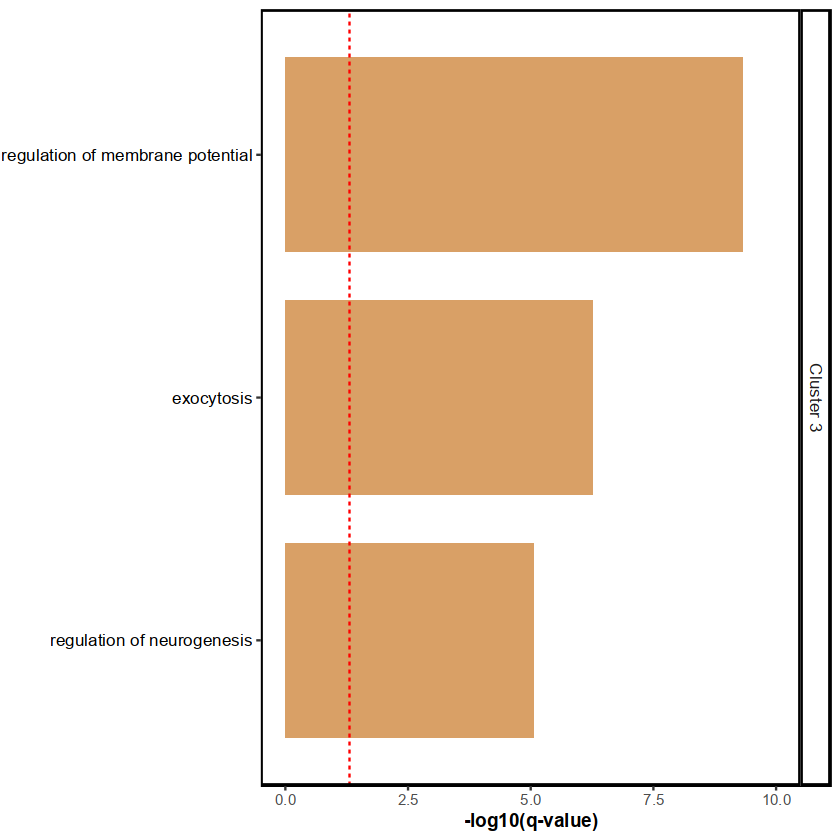

In [57]:
ggplot(plot_data, aes(x = logQ, y = reorder(Description, logQ))) +
  geom_col(aes(fill = Category), width = 0.8) +
  coord_cartesian(xlim = c(0, 10)) +
  facet_grid(Category ~ ., scales = "free_y", space = "free_y") +
  geom_vline(xintercept = -log10(0.05), color = "red", linetype = "dashed", linewidth = 0.5) +
  scale_fill_manual(values = c("Cluster 3" = "#D9A066")) +
  theme_bw() +
  labs(x = "-log10(q-value)", y = NULL) +
  theme(
    strip.background = element_rect(fill = "white", color = "black", linewidth = 1),
    strip.text = element_text(size = 10),
    strip.text.y = element_text(angle = 270),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.y = element_blank(),
    axis.text.y = element_text(color = "black", size = 10),panel.grid = element_blank(),legend.position = "none",
    axis.title.x = element_text(face = "bold")
  )